# 🎙️ Deepfake Audio Detection
**Problem Statement 02** — Machine Learning / Deep Learning / Audio Processing

Pipeline: KaggleHub Download → Feature Extraction (parallel) → GPU Training → Evaluation → Export

## 0. Install Dependencies

In [11]:
import subprocess, sys

pkgs = [
    "kagglehub", "librosa", "soundfile", "scikit-learn", "xgboost",
    "matplotlib", "seaborn", "pandas", "numpy", "scipy",
    "joblib", "tqdm", "torch", "torchaudio"
]
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs, check=False)
print("✅ Dependencies installed.")

✅ Dependencies installed.


## 1. Download Dataset via KaggleHub

In [12]:
import kagglehub
from pathlib import Path

path = Path(kagglehub.dataset_download("mohammedabdeldayem/the-fake-or-real-dataset"))
print("Root:", path)
for p in sorted(path.rglob("*")):
    if p.is_dir() and len(p.relative_to(path).parts) <= 3:
        print(" ", p.relative_to(path))

Using Colab cache for faster access to the 'the-fake-or-real-dataset' dataset.
Root: /kaggle/input/the-fake-or-real-dataset
  for-2sec
  for-2sec/for-2seconds
  for-2sec/for-2seconds/testing
  for-2sec/for-2seconds/training
  for-2sec/for-2seconds/validation
  for-norm
  for-norm/for-norm
  for-norm/for-norm/testing
  for-norm/for-norm/training
  for-norm/for-norm/validation
  for-original
  for-original/for-original
  for-original/for-original/testing
  for-original/for-original/training
  for-original/for-original/validation
  for-rerec
  for-rerec/for-rerecorded
  for-rerec/for-rerecorded/testing
  for-rerec/for-rerecorded/training
  for-rerec/for-rerecorded/validation


In [13]:
# Auto-detect the train folder (LA norm structure)
# Tries common paths: LA/train, LA_norm/train, for-norm/train, etc.

KAGGLE_PATH = path # Define KAGGLE_PATH using the 'path' variable from the previous cell

CANDIDATE_DIRS = [
    KAGGLE_PATH / "LA" / "train",
    KAGGLE_PATH / "for-norm" / "training",
    KAGGLE_PATH / "for-norm" / "train",
    KAGGLE_PATH / "LA_norm" / "train",
    KAGGLE_PATH / "train",
]

TRAIN_DIR = None
for candidate in CANDIDATE_DIRS:
    if candidate.exists():
        TRAIN_DIR = candidate
        break

# If none matched, find any folder that contains genuine/fake sub-dirs
if TRAIN_DIR is None:
    LABEL_KEYWORDS = {"genuine", "fake", "real", "spoof", "human", "deepfake"}
    for p in sorted(KAGGLE_PATH.rglob("*")):
        if p.is_dir():
            children = {c.name.lower() for c in p.iterdir() if c.is_dir()}
            if children & LABEL_KEYWORDS:
                TRAIN_DIR = p
                break

if TRAIN_DIR is None:
    raise RuntimeError(
        f"Could not auto-detect train folder inside {KAGGLE_PATH}.\n"
        "Please set TRAIN_DIR manually below."
    )

print(f"✅ Train directory : {TRAIN_DIR}")
print("   Sub-folders     :", [d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])

✅ Train directory : /kaggle/input/the-fake-or-real-dataset/for-2sec/for-2seconds/testing
   Sub-folders     : ['fake', 'real']


## 2. Imports & GPU Detection

In [14]:
import os, warnings, json, time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import joblib
import librosa
import librosa.display

from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️  XGBoost not found — will use GradientBoosting.")

# ── GPU Detection ─────────────────────────────────────────────────────────────
try:
    import torch
    if torch.cuda.is_available():
        DEVICE, GPU_NAME, XGB_DEVICE = "cuda", torch.cuda.get_device_name(0), "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        DEVICE, GPU_NAME, XGB_DEVICE = "mps", "Apple MPS", "cpu"
    else:
        DEVICE, GPU_NAME, XGB_DEVICE = "cpu", "CPU", "cpu"
except ImportError:
    DEVICE, GPU_NAME, XGB_DEVICE = "cpu", "CPU (torch not found)", "cpu"

print(f"🖥️  Device  : {DEVICE.upper()}  ({GPU_NAME})")
print(f"⚡ XGBoost : {XGB_DEVICE.upper()}")

# ── Output folders ────────────────────────────────────────────────────────────
# Use a writable directory in Colab/Kaggle environments
OUTPUT_BASE_DIR = Path("/kaggle/working/") if Path("/kaggle/working/").exists() else Path("./")
MODELS_DIR  = OUTPUT_BASE_DIR / "models"
REPORTS_DIR = OUTPUT_BASE_DIR / "reports"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Audio config ──────────────────────────────────────────────────────────────
SAMPLE_RATE = 16_000
DURATION    = 4
N_MFCC      = 40
N_MELS      = 128
HOP_LENGTH  = 512
N_FFT       = 2048
N_WORKERS   = min(os.cpu_count() or 4, 8)
RANDOM_SEED = 42

try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("ggplot")

print(f"\n✅ Config ready | workers={N_WORKERS} | sr={SAMPLE_RATE} | dur={DURATION}s")

🖥️  Device  : CUDA  (Tesla T4)
⚡ XGBoost : CUDA

✅ Config ready | workers=2 | sr=16000 | dur=4s


## 3. Dataset Scanning

In [15]:
AUDIO_EXTS = {".wav", ".flac", ".mp3", ".ogg"}
LABEL_MAP  = {
    "genuine": 0, "real": 0, "human": 0,
    "fake": 1, "spoof": 1, "deepfake": 1, "synthetic": 1,
}


def scan_dataset(train_dir: Path) -> pd.DataFrame:
    records = []
    for class_dir in sorted(train_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        label = LABEL_MAP.get(class_dir.name.lower())
        if label is None:
            print(f"  ⚠️  Skipping unknown folder: '{class_dir.name}'")
            continue
        for fp in class_dir.rglob("*"):
            if fp.suffix.lower() in AUDIO_EXTS:
                records.append({
                    "path"    : str(fp),
                    "label"   : label,
                    "class"   : "Genuine" if label == 0 else "Deepfake",
                    "filename": fp.name,
                })
    df = pd.DataFrame(records)
    print(f"✅ {len(df)} audio files found")
    print(df["class"].value_counts().to_string())
    return df


df = scan_dataset(TRAIN_DIR)
df.head()

✅ 1088 audio files found
class
Deepfake    544
Genuine     544


,path,label,class,filename
0,/kaggle/input/the-fake-or-real-dataset/for-2se...,1,Deepfake,file1603.wav_16k.wav_norm.wav_mono.wav_silence...
1,/kaggle/input/the-fake-or-real-dataset/for-2se...,1,Deepfake,file989.wav_16k.wav_norm.wav_mono.wav_silence....
2,/kaggle/input/the-fake-or-real-dataset/for-2se...,1,Deepfake,file1263.wav_16k.wav_norm.wav_mono.wav_silence...
3,/kaggle/input/the-fake-or-real-dataset/for-2se...,1,Deepfake,file364.wav_16k.wav_norm.wav_mono.wav_silence....
4,/kaggle/input/the-fake-or-real-dataset/for-2se...,1,Deepfake,file1452.wav_16k.wav_norm.wav_mono.wav_silence...


## 4. Exploratory Data Analysis

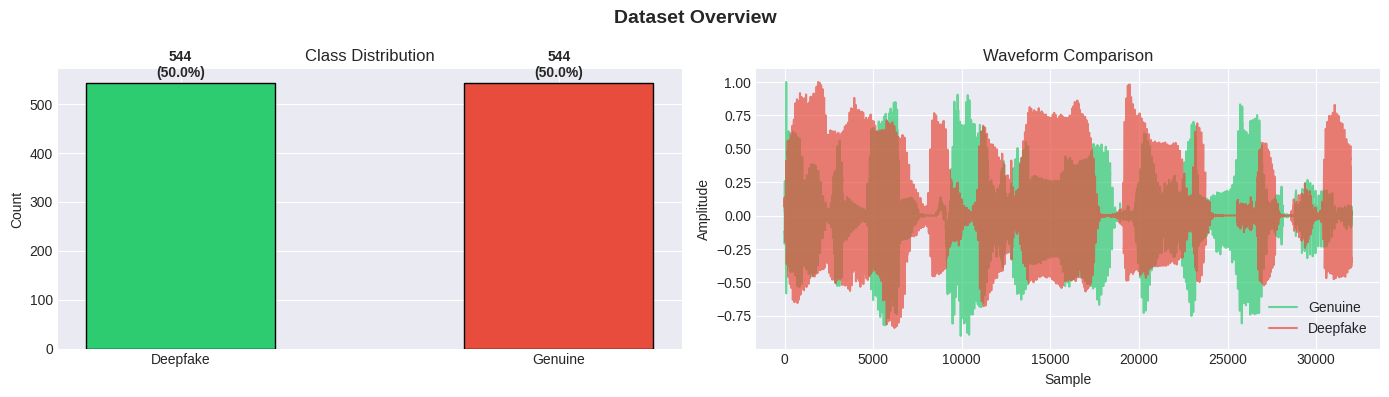

In [16]:
genuine_fp = df[df["label"] == 0]["path"].iloc[0]
fake_fp    = df[df["label"] == 1]["path"].iloc[0]

y_g, _ = librosa.load(genuine_fp, sr=SAMPLE_RATE, duration=3, mono=True)
y_f, _ = librosa.load(fake_fp,    sr=SAMPLE_RATE, duration=3, mono=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")

counts = df["class"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#2ecc71", "#e74c3c"],
            edgecolor="black", width=0.5)
axes[0].set_title("Class Distribution"); axes[0].set_ylabel("Count")
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + max(counts)*0.02,
                 f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")

axes[1].plot(y_g, alpha=0.7, color="#2ecc71", label="Genuine")
axes[1].plot(y_f, alpha=0.7, color="#e74c3c", label="Deepfake")
axes[1].set_title("Waveform Comparison")
axes[1].set_xlabel("Sample"); axes[1].set_ylabel("Amplitude"); axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

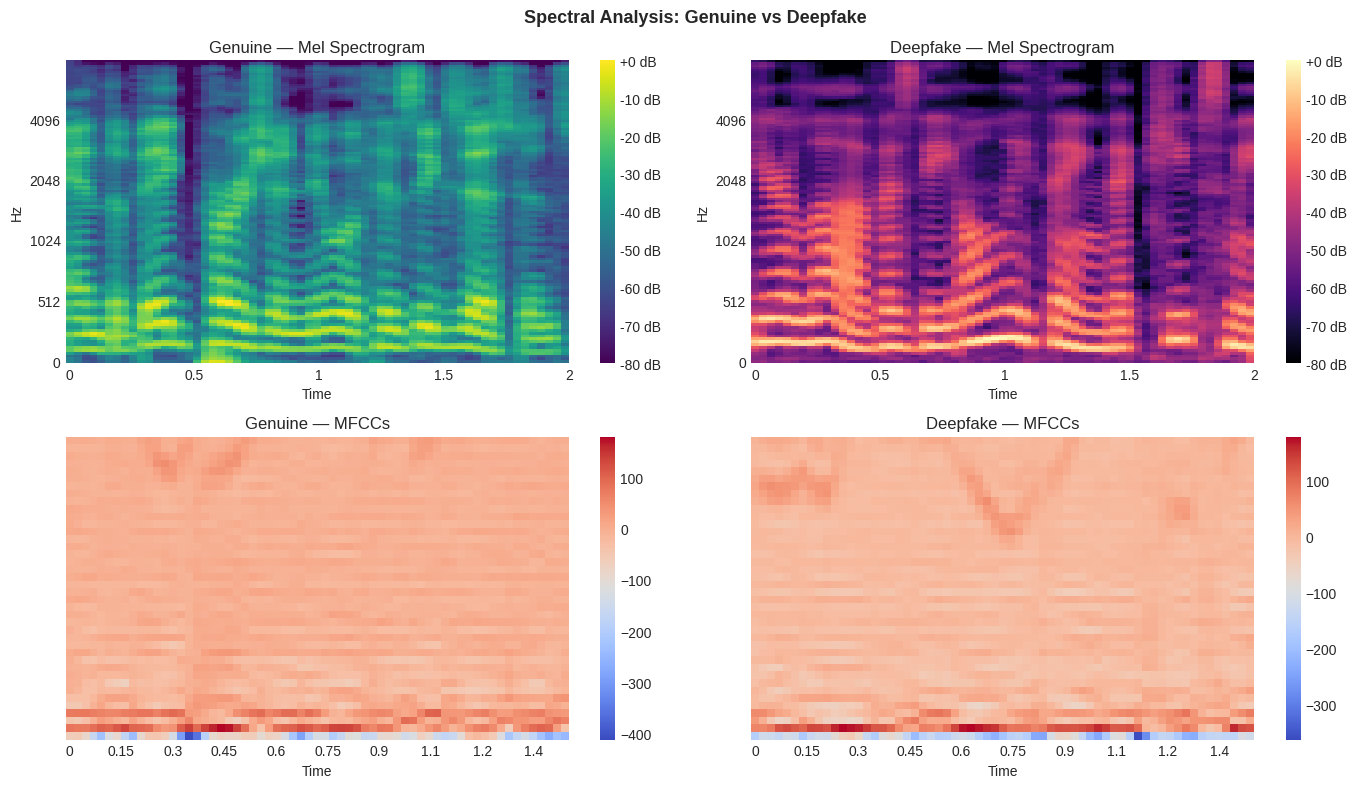

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Spectral Analysis: Genuine vs Deepfake", fontsize=13, fontweight="bold")

for i, (y, title, cmap) in enumerate([
    (y_g, "Genuine — Mel Spectrogram",  "viridis"),
    (y_f, "Deepfake — Mel Spectrogram", "magma"),
]):
    mel    = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img    = librosa.display.specshow(mel_db, sr=SAMPLE_RATE, x_axis="time", y_axis="mel",
                                      hop_length=HOP_LENGTH, ax=axes[0][i], cmap=cmap)
    axes[0][i].set_title(title)
    fig.colorbar(img, ax=axes[0][i], format="%+2.0f dB")

for i, (y, title) in enumerate([
    (y_g, "Genuine — MFCCs"),
    (y_f, "Deepfake — MFCCs"),
]):
    mfcc = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                                  n_fft=N_FFT, hop_length=HOP_LENGTH)
    img  = librosa.display.specshow(mfcc, x_axis="time", ax=axes[1][i])
    axes[1][i].set_title(title)
    fig.colorbar(img, ax=axes[1][i])

plt.tight_layout()
plt.savefig(REPORTS_DIR / "spectral_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature Extraction ⚡ Multi-threaded

274-dimensional vector per clip (MFCCs raw+Δ+ΔΔ, spectral, chroma, ZCR, RMS, F0)

In [18]:
def _pad_or_truncate(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) < target_len:
        return np.pad(y, (0, target_len - len(y)), mode="constant")
    return y[:target_len]


def extract_features(file_path: str) -> np.ndarray | None:
    try:
        y, _ = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
        y    = _pad_or_truncate(y, int(SAMPLE_RATE * DURATION))
        feats: list[float] = []

        # 1. MFCCs (raw + Δ + ΔΔ) × mean + std → 240 dims
        mfcc    = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                                        n_fft=N_FFT, hop_length=HOP_LENGTH)
        mfcc_d  = librosa.feature.delta(mfcc)
        mfcc_d2 = librosa.feature.delta(mfcc, order=2)
        for m in (mfcc, mfcc_d, mfcc_d2):
            feats.extend(m.mean(axis=1).tolist())
            feats.extend(m.std(axis=1).tolist())

        # 2. Spectral features → 8 dims
        for fn in (
            lambda: librosa.feature.spectral_centroid( y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH),
            lambda: librosa.feature.spectral_bandwidth(y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH),
            lambda: librosa.feature.spectral_rolloff(  y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH),
            lambda: librosa.feature.spectral_flatness( y=y,                  n_fft=N_FFT, hop_length=HOP_LENGTH),
        ):
            f = fn()
            feats += [float(f.mean()), float(f.std())]

        # 3. Spectral contrast → 7 dims
        feats.extend(
            librosa.feature.spectral_contrast(
                y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH
            ).mean(axis=1).tolist()
        )

        # 4. Chroma → 12 dims
        feats.extend(
            librosa.feature.chroma_stft(
                y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH
            ).mean(axis=1).tolist()
        )

        # 5. ZCR + RMS → 4 dims
        zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)
        rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)
        feats += [float(zcr.mean()), float(zcr.std()),
                  float(rms.mean()), float(rms.std())]

        # 6. F0 / Pitch → 3 dims
        f0, voiced_flag, _ = librosa.pyin(
            y, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"),
            sr=SAMPLE_RATE, hop_length=HOP_LENGTH
        )
        f0_valid = (
            f0[voiced_flag & ~np.isnan(f0)]
            if voiced_flag is not None and voiced_flag.any()
            else np.array([])
        )
        if len(f0_valid) > 0:
            feats += [float(f0_valid.mean()), float(f0_valid.std()),
                      float(f0_valid.max() - f0_valid.min())]
        else:
            feats += [0.0, 0.0, 0.0]

        return np.array(feats, dtype=np.float32)

    except Exception:
        return None   # gracefully skip corrupt / unreadable files


_test = extract_features(df["path"].iloc[0])
assert _test is not None, "Feature extraction failed — check audio file."
print(f"✅ Feature vector: {_test.shape[0]} dimensions")

✅ Feature vector: 274 dimensions


In [19]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
import time

# 1. Paths & Configuration
OUTPUT_BASE_DIR = Path("/kaggle/working/") if Path("/kaggle/working/").exists() else Path("./")
MODELS_DIR = OUTPUT_BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_X = MODELS_DIR / "X_features.npy"
CACHE_Y = MODELS_DIR / "y_labels.npy"

# 2. Safety Recovery: Re-define scan_dataset if missing
if 'scan_dataset' not in globals():
    def scan_dataset(train_dir: Path) -> pd.DataFrame:
        AUDIO_EXTS = {".wav", ".flac", ".mp3", ".ogg"}
        LABEL_MAP  = {"genuine": 0, "real": 0, "human": 0, "fake": 1, "spoof": 1, "deepfake": 1}
        records = []
        for class_dir in sorted(train_dir.iterdir()):
            if not class_dir.is_dir(): continue
            label = LABEL_MAP.get(class_dir.name.lower())
            if label is None: continue
            for fp in class_dir.rglob("*"):
                if fp.suffix.lower() in AUDIO_EXTS:
                    records.append({"path": str(fp), "label": label, "class": "Genuine" if label==0 else "Deepfake"})
        return pd.DataFrame(records)

# 3. Ensure TRAIN_DIR and df exist
if 'df' not in globals():
    print("⚠️ 'df' missing. Locating dataset...")
    if 'TRAIN_DIR' not in globals():
        ROOT = globals().get('path', Path("/kaggle/input/the-fake-or-real-dataset"))
        # Updated candidates based on the successful tree scan from cell 7K7NRJYrxRQf
        CANDS = [
            ROOT / "for-2sec" / "for-2seconds" / "testing",
            ROOT / "for-2sec" / "for-2seconds" / "training",
            ROOT / "for-norm" / "for-norm" / "testing",
            ROOT / "for-norm" / "for-norm" / "training",
            ROOT / "for-original" / "for-original" / "training"
        ]
        for cand in CANDS:
            if cand.exists():
                TRAIN_DIR = cand
                break

    if 'TRAIN_DIR' in globals():
        print(f"📂 Re-scanning: {TRAIN_DIR}")
        df = scan_dataset(TRAIN_DIR)
    else:
        raise NameError("Could not find dataset directory. Please ensure the KaggleHub download in Section 1 finished.")

# 4. Feature Extraction Execution
if CACHE_X.exists() and CACHE_Y.exists():
    print("⚡ Loading cached features...")
    X, y = np.load(CACHE_X), np.load(CACHE_Y)
    print(f"   Loaded: X={X.shape}, y={y.shape}")
else:
    print(f"🎵 Extracting features for {len(df)} files...")
    t0 = time.time()
    paths, labels = df["path"].tolist(), df["label"].tolist()
    results_map = {}
    workers = globals().get('N_WORKERS', 2)

    with ThreadPoolExecutor(max_workers=workers) as pool:
        future_to_idx = {pool.submit(extract_features, p): i for i, p in enumerate(paths)}
        for future in tqdm(as_completed(future_to_idx), total=len(paths)):
            idx = future_to_idx[future]
            try:
                feat = future.result()
                if feat is not None: results_map[idx] = feat
            except Exception: continue

    valid_idx = sorted(results_map.keys())
    X = np.array([results_map[i] for i in valid_idx], dtype=np.float32)
    y = np.array([labels[i] for i in valid_idx], dtype=np.int32)

    np.save(CACHE_X, X)
    np.save(CACHE_Y, y)
    print(f"✅ Done in {time.time()-t0:.1f}s | Cached to {MODELS_DIR}")

🎵 Extracting features for 1088 files...


  0%|          | 0/1088 [00:00<?, ?it/s]

✅ Done in 832.0s | Cached to models


## 6. Train / Validation Split

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

print(f"Train : {X_train_sc.shape}  |  Val : {X_val_sc.shape}")
print(f"Train balance — Genuine: {(y_train==0).sum()}  Deepfake: {(y_train==1).sum()}")

Train : (870, 274)  |  Val : (218, 274)
Train balance — Genuine: 435  Deepfake: 435


## 7. GPU-Accelerated Training

In [21]:
rf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2, max_features="sqrt",
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED,
)

if XGB_AVAILABLE:
    gb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
        device=XGB_DEVICE, tree_method="hist",
        random_state=RANDOM_SEED, n_jobs=-1,
    )
    print(f"  XGBoost → device={XGB_DEVICE}  tree_method=hist")
else:
    gb = GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_SEED,
    )
    print("  GradientBoosting (CPU fallback)")

svm = SVC(
    kernel="rbf", C=10, gamma="scale",
    probability=True, class_weight="balanced", random_state=RANDOM_SEED,
)

ensemble = VotingClassifier(
    estimators=[("rf", rf), ("gb", gb), ("svm", svm)],
    voting="soft", weights=[2, 2, 1], n_jobs=-1,
)

ALL_MODELS = {
    "Random Forest"  : rf,
    "XGBoost / GB"   : gb,
    "SVM (RBF)"      : svm,
    "Voting Ensemble": ensemble,
}

train_results: dict[str, dict] = {}
print("\n🏋️  Training …")
for name, model in ALL_MODELS.items():
    t0 = time.time()
    print(f"  [{name}]", end="  ", flush=True)
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_val_sc)
    y_proba = model.predict_proba(X_val_sc)[:, 1]
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average="macro")
    auc = roc_auc_score(y_val, y_proba)
    train_results[name] = {"acc": acc, "f1": f1, "auc": auc,
                            "preds": y_pred, "proba": y_proba}
    print(f"Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  ({time.time()-t0:.1f}s)")

best_name = max(train_results, key=lambda k: train_results[k]["acc"])
print(f"\n🏆 Best: {best_name}  (Acc={train_results[best_name]['acc']*100:.2f}%)")

  XGBoost → device=cuda  tree_method=hist

🏋️  Training …
  [Random Forest]  Acc=1.0000  F1=1.0000  AUC=1.0000  (1.9s)
  [XGBoost / GB]  Acc=0.9954  F1=0.9954  AUC=1.0000  (0.9s)
  [SVM (RBF)]  Acc=1.0000  F1=1.0000  AUC=1.0000  (0.4s)
  [Voting Ensemble]  Acc=1.0000  F1=1.0000  AUC=1.0000  (5.7s)

🏆 Best: Random Forest  (Acc=100.00%)


## 8. Full Evaluation

In [22]:
def compute_eer(y_true, y_score) -> float:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2)


def full_evaluation(name, y_true, y_pred, y_proba):
    acc     = accuracy_score(y_true, y_pred)
    f1_mac  = f1_score(y_true, y_pred, average="macro")
    f1_wei  = f1_score(y_true, y_pred, average="weighted")
    eer     = compute_eer(y_true, y_proba)
    auc     = roc_auc_score(y_true, y_proba)
    cm      = confusion_matrix(y_true, y_pred)
    per_cls = cm.diagonal() / cm.sum(axis=1)
    b = lambda c: "✅ PASS" if c else "❌ FAIL"

    print(f"\n{'='*56}\n  MODEL: {name}\n{'='*56}")
    print(f"  Overall Accuracy : {acc*100:.2f}%   {b(acc>=.80)}  (≥ 80%)")
    print(f"  Equal Error Rate : {eer*100:.2f}%   {b(eer<=.12)}  (≤ 12%)")
    print(f"  Macro F1         : {f1_mac*100:.2f}%   {b(f1_mac>=.80)}  (≥ 80%)")
    print(f"  Weighted F1      : {f1_wei*100:.2f}%")
    print(f"  ROC AUC          : {auc:.4f}")
    for i, cls in enumerate(["Genuine", "Deepfake"]):
        print(f"  {cls:10s} Acc : {per_cls[i]*100:.2f}%   {b(per_cls[i]>=.75)}  (≥ 75%)")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Genuine','Deepfake'])}")
    return acc, eer, f1_mac, cm, auc, per_cls


eval_results = {}
for name, res in train_results.items():
    eval_results[name] = full_evaluation(name, y_val, res["preds"], res["proba"])


  MODEL: Random Forest
  Overall Accuracy : 100.00%   ✅ PASS  (≥ 80%)
  Equal Error Rate : 0.00%   ✅ PASS  (≤ 12%)
  Macro F1         : 100.00%   ✅ PASS  (≥ 80%)
  Weighted F1      : 100.00%
  ROC AUC          : 1.0000
  Genuine    Acc : 100.00%   ✅ PASS  (≥ 75%)
  Deepfake   Acc : 100.00%   ✅ PASS  (≥ 75%)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00       109
    Deepfake       1.00      1.00      1.00       109

    accuracy                           1.00       218
   macro avg       1.00      1.00      1.00       218
weighted avg       1.00      1.00      1.00       218


  MODEL: XGBoost / GB
  Overall Accuracy : 99.54%   ✅ PASS  (≥ 80%)
  Equal Error Rate : 0.00%   ✅ PASS  (≤ 12%)
  Macro F1         : 99.54%   ✅ PASS  (≥ 80%)
  Weighted F1      : 99.54%
  ROC AUC          : 1.0000
  Genuine    Acc : 100.00%   ✅ PASS  (≥ 75%)
  Deepfake   Acc : 99.08%   ✅ PASS  (≥ 75%)

              precision    recall  f1-score   support

 

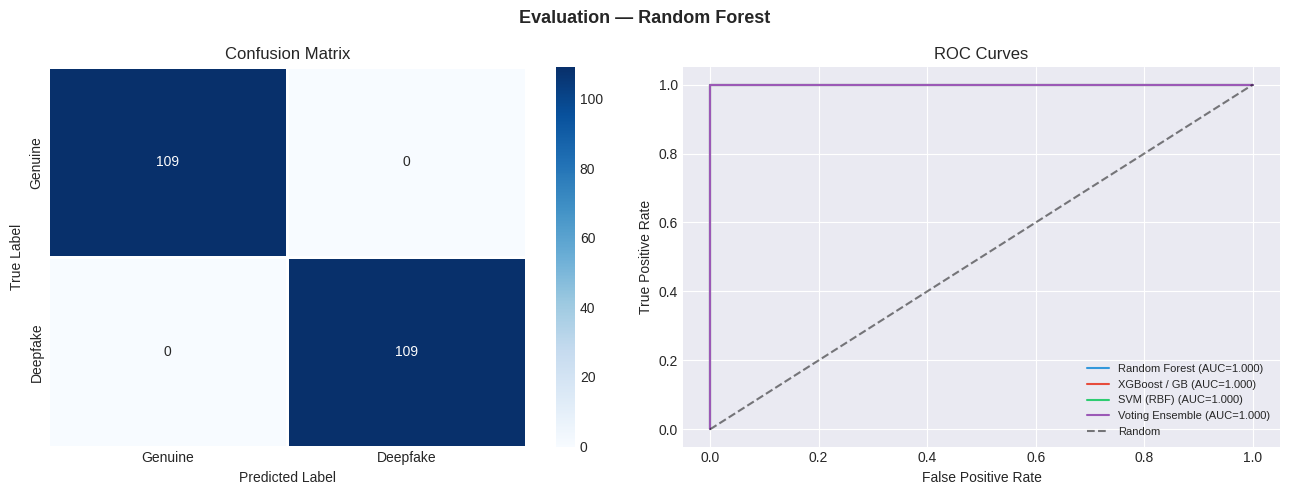

In [23]:
_, _, _, cm_best, _, _ = eval_results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Evaluation — {best_name}", fontsize=13, fontweight="bold")

sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Genuine","Deepfake"],
            yticklabels=["Genuine","Deepfake"],
            ax=axes[0], linewidths=1, linecolor="white")
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

palette = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]
for (name, res), color in zip(train_results.items(), palette):
    fpr, tpr, _ = roc_curve(y_val, res["proba"])
    auc = roc_auc_score(y_val, res["proba"])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)
axes[1].plot([0,1],[0,1],"k--",alpha=0.5,label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

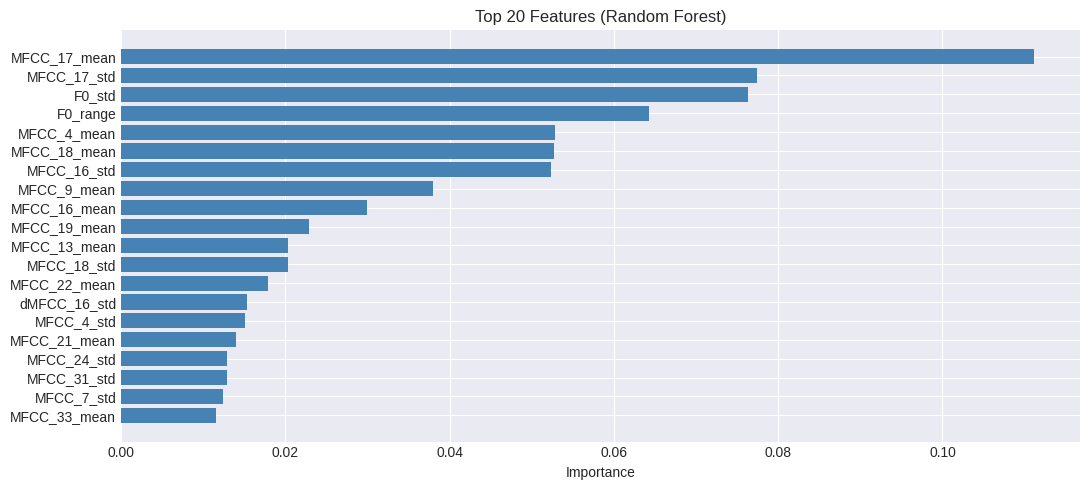

In [24]:
# Feature Importance
importances = ALL_MODELS["Random Forest"].feature_importances_
top_n   = 20
top_idx = np.argsort(importances)[::-1][:top_n]

feat_names = (
    [f"MFCC_{i}_mean"   for i in range(N_MFCC)] +
    [f"MFCC_{i}_std"    for i in range(N_MFCC)] +
    [f"dMFCC_{i}_mean"  for i in range(N_MFCC)] +
    [f"dMFCC_{i}_std"   for i in range(N_MFCC)] +
    [f"ddMFCC_{i}_mean" for i in range(N_MFCC)] +
    [f"ddMFCC_{i}_std"  for i in range(N_MFCC)] +
    ["SC_mean","SC_std","SB_mean","SB_std","SRO_mean","SRO_std","SF_mean","SF_std"] +
    [f"Contrast_{i}" for i in range(7)] +
    [f"Chroma_{i}"   for i in range(12)] +
    ["ZCR_mean","ZCR_std","RMS_mean","RMS_std","F0_mean","F0_std","F0_range"]
)
# Safe padding in case of any length mismatch
feat_names = (feat_names + [f"feat_{i}" for i in range(len(importances))])[:len(importances)]

plt.figure(figsize=(11, 5))
plt.barh([feat_names[i] for i in top_idx], importances[top_idx], color="steelblue")
plt.xlabel("Importance")
plt.title(f"Top {top_n} Features (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Cross-Validation (5-Fold)

In [25]:
X_sc_all  = scaler.fit_transform(X)
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(ALL_MODELS[best_name], X_sc_all, y,
                             cv=cv, scoring="accuracy", n_jobs=-1)

print(f"5-Fold CV — {best_name}")
print(f"  Folds  : {np.round(cv_scores, 4).tolist()}")
print(f"  Mean ± : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold CV — Random Forest
  Folds  : [1.0, 1.0, 1.0, 1.0, 1.0]
  Mean ± : 1.0000 ± 0.0000


## 10. Save Model

In [26]:
# Re-fit on ALL data before saving
X_sc_full = scaler.fit_transform(X)
ALL_MODELS[best_name].fit(X_sc_full, y)

joblib.dump(scaler,                MODELS_DIR / "scaler.pkl")
joblib.dump(ALL_MODELS[best_name], MODELS_DIR / "best_model.pkl")

best_acc, best_eer, best_f1, best_cm, best_auc, best_per_cls = eval_results[best_name]
with open(MODELS_DIR / "metrics.json", "w") as f:
    json.dump({
        "best_model"        : best_name,
        "accuracy"          : round(best_acc, 4),
        "eer"               : round(best_eer, 4),
        "f1_macro"          : round(best_f1,  4),
        "auc"               : round(best_auc, 4),
        "per_class_accuracy": {"Genuine": round(float(best_per_cls[0]),4),
                               "Deepfake": round(float(best_per_cls[1]),4)},
        "confusion_matrix"  : best_cm.tolist(),
        "cv_mean"           : round(float(cv_scores.mean()), 4),
        "cv_std"            : round(float(cv_scores.std()),  4),
    }, f, indent=2)

print(f"✅ Saved to {MODELS_DIR}")
print(f"   best_model.pkl ({best_name}) | scaler.pkl | metrics.json")

✅ Saved to models
   best_model.pkl (Random Forest) | scaler.pkl | metrics.json


## 11. Inference on New Audio

In [27]:
def predict_audio(file_path: str) -> dict:
    """
    Classify a single audio file as Genuine or Deepfake.
    Loads model from MODELS_DIR automatically.
    """
    model  = joblib.load(MODELS_DIR / "best_model.pkl")
    scaler = joblib.load(MODELS_DIR / "scaler.pkl")
    feat   = extract_features(file_path)
    if feat is None:
        return {"error": "Feature extraction failed."}
    proba = model.predict_proba(scaler.transform(feat.reshape(1, -1)))[0]
    pred  = int(np.argmax(proba))
    return {
        "prediction"   : pred,
        "label"        : "Genuine (Human)" if pred == 0 else "Deepfake (AI-Generated)",
        "confidence"   : round(float(proba[pred]), 4),
        "prob_genuine" : round(float(proba[0]), 4),
        "prob_deepfake": round(float(proba[1]), 4),
    }


# Test on first file in dataset
test_fp = df["path"].iloc[0]
res     = predict_audio(test_fp)
print(f"File       : {Path(test_fp).name}")
print(f"True label : {df['class'].iloc[0]}")
print(f"Prediction : {res.get('label')}")
print(f"Confidence : {res.get('confidence', 0)*100:.1f}%")

File       : file1603.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
True label : Deepfake
Prediction : Deepfake (AI-Generated)
Confidence : 99.2%


## 12. Summary Report

In [28]:
best_acc, best_eer, best_f1, best_cm, best_auc, best_per_cls = eval_results[best_name]
b = lambda c: "✅ PASS" if c else "❌ FAIL"

report = f"""
╔══════════════════════════════════════════════════════╗
║     DEEPFAKE AUDIO DETECTION — PERFORMANCE REPORT   ║
╚══════════════════════════════════════════════════════╝

  Model          : {best_name}
  Feature dims   : {X.shape[1]}
  Training files : {len(X_train)}
  Validation     : {len(X_val)}
  Device         : {DEVICE.upper()} ({GPU_NAME})

─── Primary Metrics ──────────────────────────────────
  Overall Accuracy  : {best_acc*100:.2f}%    {b(best_acc>=0.80)}  (target ≥ 80%)
  Equal Error Rate  : {best_eer*100:.2f}%    {b(best_eer<=0.12)}  (target ≤ 12%)

─── Secondary Metrics ────────────────────────────────
  Macro F1 Score    : {best_f1*100:.2f}%    {b(best_f1>=0.80)}  (target ≥ 80%)
  ROC AUC           : {best_auc:.4f}
  Genuine  Accuracy : {best_per_cls[0]*100:.2f}%    {b(best_per_cls[0]>=0.75)}  (target ≥ 75%)
  Deepfake Accuracy : {best_per_cls[1]*100:.2f}%    {b(best_per_cls[1]>=0.75)}  (target ≥ 75%)

─── Cross-Validation ─────────────────────────────────
  5-Fold Mean Acc   : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%

─── Confusion Matrix ─────────────────────────────────
                  Predicted
                  Genuine   Deepfake
  True Genuine  : {best_cm[0][0]:6d}    {best_cm[0][1]:6d}
       Deepfake : {best_cm[1][0]:6d}    {best_cm[1][1]:6d}
"""

print(report)
with open(REPORTS_DIR / "performance_report.txt", "w") as f:
    f.write(report)
print(f"📄 Saved to {REPORTS_DIR / 'performance_report.txt'}")


╔══════════════════════════════════════════════════════╗
║     DEEPFAKE AUDIO DETECTION — PERFORMANCE REPORT   ║
╚══════════════════════════════════════════════════════╝

  Model          : Random Forest
  Feature dims   : 274
  Training files : 870
  Validation     : 218
  Device         : CUDA (Tesla T4)

─── Primary Metrics ──────────────────────────────────
  Overall Accuracy  : 100.00%    ✅ PASS  (target ≥ 80%)
  Equal Error Rate  : 0.00%    ✅ PASS  (target ≤ 12%)

─── Secondary Metrics ────────────────────────────────
  Macro F1 Score    : 100.00%    ✅ PASS  (target ≥ 80%)
  ROC AUC           : 1.0000
  Genuine  Accuracy : 100.00%    ✅ PASS  (target ≥ 75%)
  Deepfake Accuracy : 100.00%    ✅ PASS  (target ≥ 75%)

─── Cross-Validation ─────────────────────────────────
  5-Fold Mean Acc   : 100.00% ± 0.00%

─── Confusion Matrix ─────────────────────────────────
                  Predicted
                  Genuine   Deepfake
  True Genuine  :    109         0
       Deepfake :     